# Telco Customer Churn Analysis

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [167]:
df=pd.read_csv('Downloads/new churn data.csv')

In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerid         7043 non-null   object 
 1   city               7043 non-null   object 
 2   gender             7043 non-null   object 
 3   senior_citizen     7043 non-null   object 
 4   partner            7043 non-null   object 
 5   dependents         7043 non-null   object 
 6   tenure_months      7043 non-null   int64  
 7   contract           7043 non-null   object 
 8   payment_method     7043 non-null   object 
 9   monthly_charges    7043 non-null   float64
 10  total_charges      7032 non-null   float64
 11  churn_label        7043 non-null   object 
 12  churn_score        7043 non-null   int64  
 13  churn_reason       1869 non-null   object 
 14  churn_flag         7043 non-null   int64  
 15  avg_monthly_value  7032 non-null   float64
 16  contract_risks     7043 

In [169]:
df.head()

,customerid,city,gender,senior_citizen,partner,dependents,tenure_months,contract,payment_method,monthly_charges,...,churn_label,churn_score,churn_reason,churn_flag,avg_monthly_value,contract_risks,payment_risk,engagement_score,cltv,high_value
0,5167-ZFFMM,Indio,Male,No,No,No,1,Month-to-month,Credit card (automatic),90.85,...,Yes,81,Network reliability,1,90.850000,2,0,45.925,90.85,0
1,4895-TMWIR,Indian Wells,Male,Yes,Yes,No,11,Month-to-month,Mailed check,19.95,...,Yes,80,Limited range of services,1,19.522727,2,0,15.475,219.45,0
2,0533-BNWKF,Palm Desert,Female,Yes,Yes,No,55,Month-to-month,Electronic check,85.45,...,Yes,100,Lack of affordable download/upload speed,1,88.630909,2,1,70.225,4699.75,1
3,6599-CEBNN,Desert Hot Springs,Female,No,No,No,34,Month-to-month,Credit card (automatic),73.95,...,Yes,94,Long distance charges,1,74.248529,2,0,53.975,2514.30,1
4,0979-PHULV,Holtville,Male,No,Yes,No,69,Month-to-month,Credit card (automatic),99.45,...,Yes,80,Extra data charges,1,101.559420,2,0,84.225,6862.05,1


In [170]:
df = df.drop(['customerid','churn_reason','city'],axis=1)

## Data Cleaning

In [171]:
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')

In [172]:
## Handling missing values
df.isnull().sum()

gender                0
senior_citizen        0
partner               0
dependents            0
tenure_months         0
contract              0
payment_method        0
monthly_charges       0
total_charges        11
churn_label           0
churn_score           0
churn_flag            0
avg_monthly_value    11
contract_risks        0
payment_risk          0
engagement_score      0
cltv                  0
high_value            0
dtype: int64

In [173]:
## assuming new customers
df['total_charges'] = df['total_charges'].fillna(0)
df['avg_monthly_value'] = df['avg_monthly_value'].fillna(0)

## Univariate Analysis

In [174]:
##Churn Distribution
df['churn_flag'].value_counts(normalize=True)

churn_flag
0    0.73463
1    0.26537
Name: proportion, dtype: float64

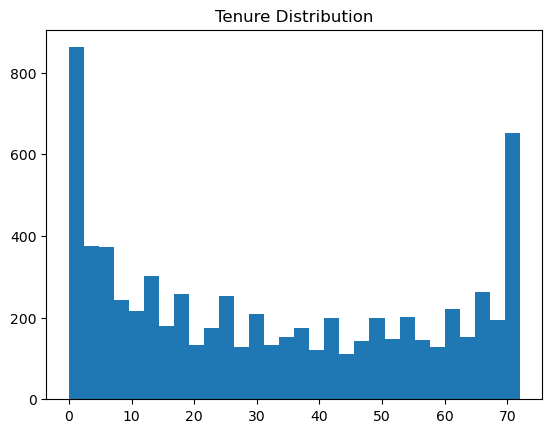

In [175]:
##Tenure Distribution
plt.hist(df['tenure_months'], bins=30)
plt.title("Tenure Distribution")
plt.show()

## Bivariate Analysis

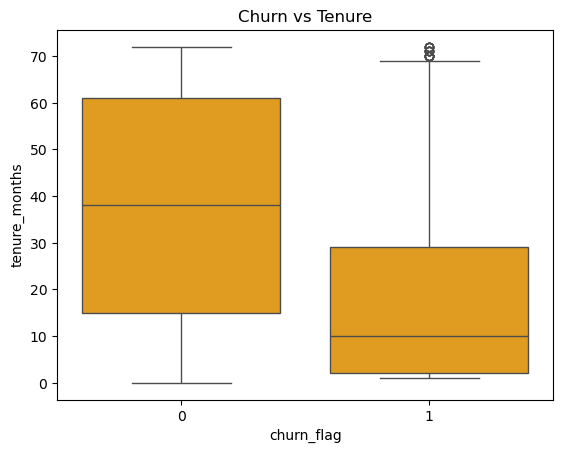

In [176]:
## Churn vs Tenure
sns.boxplot(x='churn_flag', y='tenure_months', data=df,color='orange')
plt.title('Churn vs Tenure')
plt.show()

In [177]:
## Conclusion - Customers with lower tenure are significantly more likely to churn.

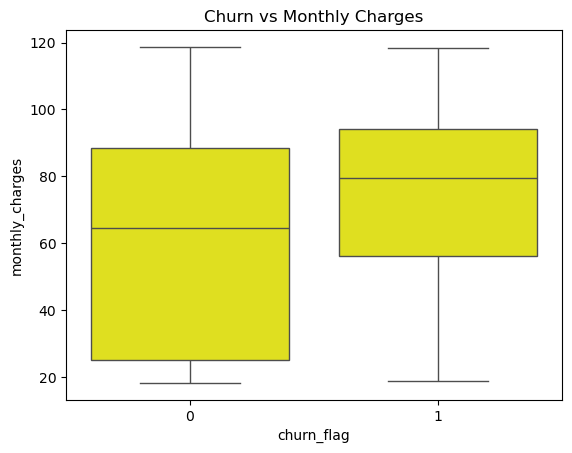

In [178]:
##Churn vs Monthly Charges
sns.boxplot(x='churn_flag', y='monthly_charges', data=df,color='yellow')
plt.title('Churn vs Monthly Charges')
plt.show()

In [179]:
## Conclusion - Higher monthly charges are associated with increased churn probability

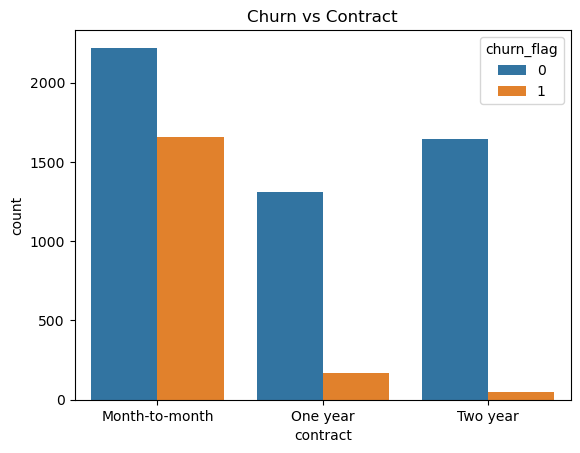

In [180]:
## Churn vs Contract
sns.countplot(x='contract', hue='churn_flag', data=df)
plt.title('Churn vs Contract')
plt.show()

In [181]:
## Conclusion - Month-to-month contract users show the highest churn rate.

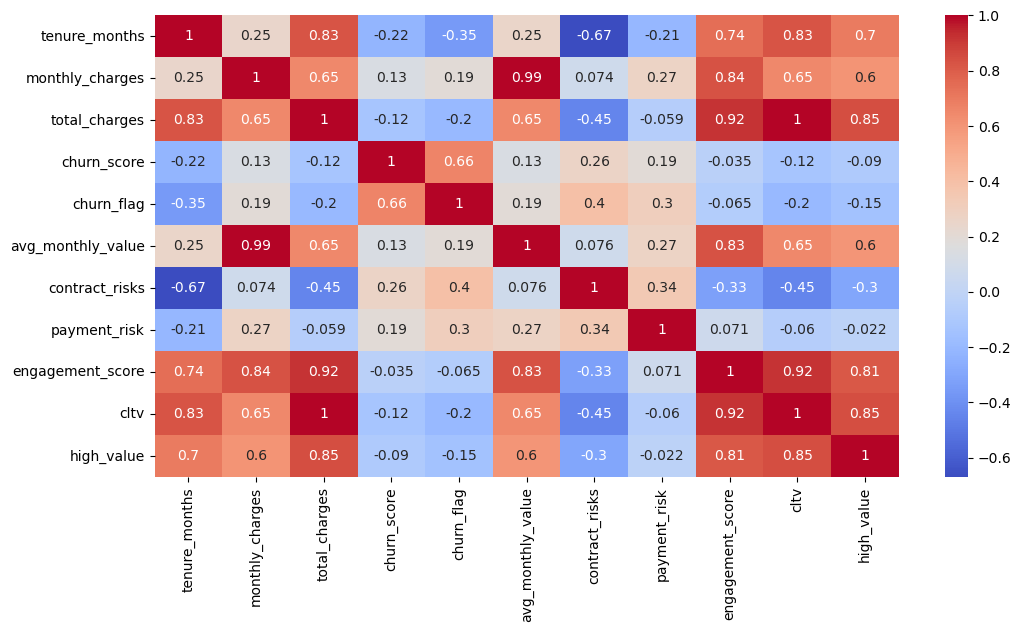

In [182]:
## Correlation
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [183]:
## Conclusion - High-value customers contribute disproportionately to revenue at risk.

## Modelling

In [184]:
df = pd.get_dummies(df, drop_first=True)

In [185]:
print(df.columns.tolist())

['tenure_months', 'monthly_charges', 'total_charges', 'churn_score', 'churn_flag', 'avg_monthly_value', 'contract_risks', 'payment_risk', 'engagement_score', 'cltv', 'high_value', 'gender_Male', 'senior_citizen_Yes', 'partner_Yes', 'dependents_Yes', 'contract_One year', 'contract_Two year', 'payment_method_Credit card (automatic)', 'payment_method_Electronic check', 'payment_method_Mailed check', 'churn_label_Yes']


In [186]:
x = df.drop(['churn_flag','churn_label_Yes','churn_score','total_charges','avg_monthly_value','cltv'],axis=1)
y = df['churn_flag']

In [187]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [188]:
## Logistic Regression (BASE MODEL)
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [189]:
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [190]:
## Prediction
y_pred = lr.predict(x_test)
y_prob = lr.predict_proba(x_test)[:, 1]

D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [191]:
## Accuracy
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.553584102200142

In [192]:
## confusion matrix
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)


array([[399, 607],
       [ 22, 381]])

In [193]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob)

0.8111097681898682

In [195]:
## Random Forest(Better Model)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [196]:
rf_pred = rf.predict(x_test)
rf_prob = rf.predict_proba(x_test)[:, 1]

In [197]:
accuracy_score(y_test, rf_pred)
roc_auc_score(y_test, rf_prob)

0.8165153002580052

In [198]:
feature_importance = pd.Series(
    rf.feature_importances_, index=x.columns
).sort_values(ascending=False)

feature_importance.head(10)

monthly_charges                    0.262963
engagement_score                   0.241516
tenure_months                      0.201129
contract_risks                     0.066779
dependents_Yes                     0.036776
contract_Two year                  0.031336
payment_risk                       0.025837
payment_method_Electronic check    0.023264
gender_Male                        0.023240
partner_Yes                        0.022787
dtype: float64

In [199]:
## Result - monthly charges, engagement score, and tenure as the strongest predictors of churn

## Predictions

In [202]:
## churn probability
df['churn_prob'] = rf.predict_proba(x)[:, 1]

In [204]:
## Revenue risk
df['revenue_at_risk'] = df['churn_prob'] * df['monthly_charges']

In [205]:
## High risk customers
high_risk = df[df['churn_prob'] > 0.7]

In [206]:
## threshold 
y_pred_custom = (y_prob > 0.7).astype(int)

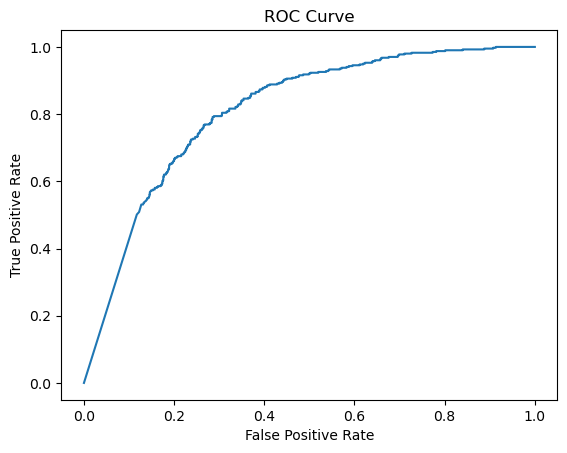

In [208]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()